Datasets loaded successfully
Training shape: (125973, 43)
Testing shape: (22544, 43)

Training model...
Training completed in 4.69 seconds

--- Model Performance ---
Accuracy : 0.7541
Precision: 0.9176
Recall   : 0.6240
F1 Score : 0.7429

Classification Report
              precision    recall  f1-score   support

      attack       0.92      0.62      0.74     12833
      normal       0.65      0.93      0.76      9711

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



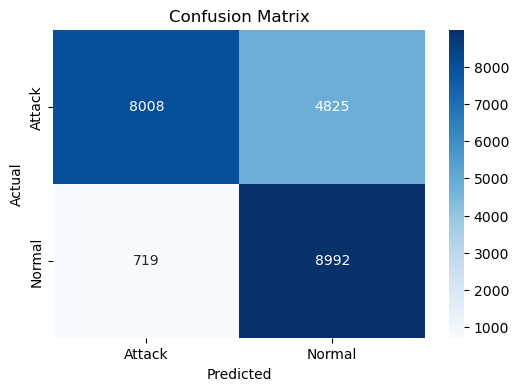

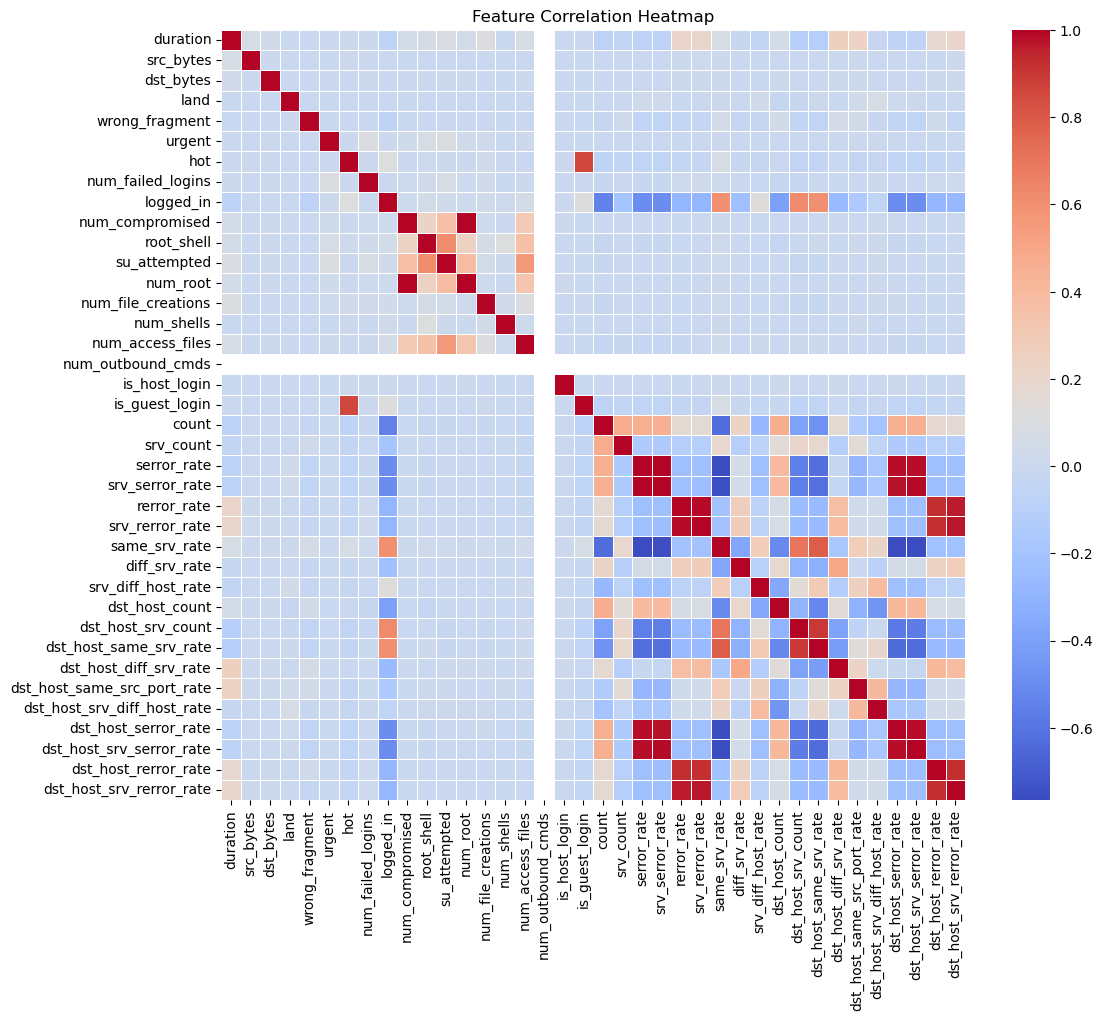


Power BI files exported successfully:
- network_traffic_powerbi.csv
- model_predictions_powerbi.csv
- confusion_matrix_powerbi.csv


In [1]:
# ================================
# 1. Imports
# ================================
import pandas as pd
import numpy as np
import time

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 2. Column Names
# ================================
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'class', 'difficulty'
]


# ================================
# 3. Load Data
# ================================
try:
    training_dataset = pd.read_csv('KDDTrain+.txt', names=column_names, header=None)
    testing_dataset = pd.read_csv('KDDTest+.txt', names=column_names, header=None)
except FileNotFoundError:
    print("Dataset files not found.")
    raise

print("Datasets loaded successfully")
print("Training shape:", training_dataset.shape)
print("Testing shape:", testing_dataset.shape)

# ================================
# 4. Create Binary Labels
# ================================
y_train = training_dataset['class'].apply(
    lambda x: 'normal' if x.strip() == 'normal' else 'attack'
)
y_test = testing_dataset['class'].apply(
    lambda x: 'normal' if x.strip() == 'normal' else 'attack'
)

# ================================
# 5. Feature Matrices
# ================================
X_train = training_dataset.drop(['class', 'difficulty'], axis=1)
X_test = testing_dataset.drop(['class', 'difficulty'], axis=1)

# ================================
# 6. Clean Data
# ================================
for df in [X_train, X_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

# ================================
# 7. Preprocessing Pipeline
# ================================
CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']
numeric_cols = [c for c in X_train.columns if c not in CATEGORICAL_COLS]

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(with_mean=False), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_COLS)
    ]
)

# ================================
# 8. Logistic Regression Pipeline
# ================================
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

print("\nTraining model...")
start_time = time.time()
log_reg_pipeline.fit(X_train, y_train)
print(f"Training completed in {time.time() - start_time:.2f} seconds")

# ================================
# 9. Predictions
# ================================
y_test_pred = log_reg_pipeline.predict(X_test)
y_test_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

# ================================
# 10. Evaluation
# ================================
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, pos_label='attack')
recall = recall_score(y_test, y_test_pred, pos_label='attack')
f1 = f1_score(y_test, y_test_pred, pos_label='attack')

print("\n--- Model Performance ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

# ================================
# 11. Confusion Matrix Plot
# ================================
cm = confusion_matrix(y_test, y_test_pred, labels=['attack', 'normal'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Attack', 'Normal'],
            yticklabels=['Attack', 'Normal'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ================================
# 12. Feature Correlation Heatmap
# ================================
X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
corr = X_train_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# ================================
# 13. EXPORT FOR POWER BI
# ================================

# Add Record ID
testing_dataset = testing_dataset.reset_index(drop=True)
testing_dataset['record_id'] = testing_dataset.index + 1

# A. Predictions table
powerbi_predictions = pd.DataFrame({
    'record_id': testing_dataset['record_id'],
    'true_label': y_test,
    'predicted_label': y_test_pred,
    'attack_probability': y_test_prob
})

powerbi_predictions.to_csv('model_predictions_powerbi.csv', index=False)

# B. Full network traffic with predictions
powerbi_data = testing_dataset.copy()
powerbi_data['true_label'] = y_test
powerbi_data['predicted_label'] = y_test_pred
powerbi_data['attack_probability'] = y_test_prob

powerbi_data.to_csv('network_traffic_powerbi.csv', index=False)

# C. Confusion matrix summary
confusion_df = pd.DataFrame({
    'Category': ['True Positive', 'False Negative', 'False Positive', 'True Negative'],
    'Count': [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
})

confusion_df.to_csv('confusion_matrix_powerbi.csv', index=False)

print("\nPower BI files exported successfully:")
print("- network_traffic_powerbi.csv")
print("- model_predictions_powerbi.csv")
print("- confusion_matrix_powerbi.csv")


In [3]:
df = pd.read_csv("network_traffic_powerbi.csv")

# Create risk level column
df["risk_level"] = pd.cut(
    df["attack_probability"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Save updated CSV
df.to_csv("network_traffic_enriched.csv", index=False)

print("Enriched network traffic csv file updated")


Enriched network traffic csv file updated


In [4]:
def error_type(row):
    if row['true_label'] == 'attack' and row['predicted_label'] == 'attack':
        return 'True Positive'
    elif row['true_label'] == 'attack' and row['predicted_label'] == 'normal':
        return 'False Negative'
    elif row['true_label'] == 'normal' and row['predicted_label'] == 'attack':
        return 'False Positive'
    else:
        return 'True Negative'

powerbi_data['error_type'] = powerbi_data.apply(error_type, axis=1)

print("Error_type row added")

Error_type row added


In [6]:
# Save updated CSV
df.to_csv("network_traffic_enriched.csv", index=False)
print("Enriched network traffic csv file updated")

Enriched network traffic csv file updated
